In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("C:/Users/senan/Downloads/archive (1)/superstore_analytics_output/superstore_cleaned_complete.csv")

# Show first 5 rows
df.head()

,category,city,country,customer_id,customer_name,discount,market,column,order_date,order_id,...,sub_category,order_year,order_month,order_quarter,order_day_of_week,is_weekend,order_week,discount_bin,profit_margin,sales_per_unit
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,Us,1,2011-01-07,CA-2011-130813,...,Paper,2011,1,1,4,0,1,0-5%,49.11,6.33
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,Us,1,2011-01-21,CA-2011-148614,...,Paper,2011,1,1,4,0,3,0-5%,48.91,9.50
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,2011-08-05,CA-2011-118962,...,Paper,2011,8,3,4,0,31,0-5%,46.87,7.00
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,2011-08-05,CA-2011-118962,...,Paper,2011,8,3,4,0,31,0-5%,47.98,55.50
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,Us,1,2011-09-29,CA-2011-146969,...,Paper,2011,9,3,3,0,39,0-5%,51.84,6.00


In [2]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (51290, 32)

Columns:
Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'column', 'order_date', 'order_id',
       'order_priority', 'product_id', 'product_name', 'profit', 'quantity',
       'region', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost',
       'state', 'sub_category', 'order_year', 'order_month', 'order_quarter',
       'order_day_of_week', 'is_weekend', 'order_week', 'discount_bin',
       'profit_margin', 'sales_per_unit'],
      dtype='object')

Data Types:
category              object
city                  object
country               object
customer_id           object
customer_name         object
discount             float64
market                object
column                 int64
order_date            object
order_id              object
order_priority        object
product_id            object
product_name          object
profit               float64
quantity               int64
region  

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Convert dates into datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# Create YearMonth column
df['year_month'] = df['order_date'].dt.to_period('M')

# Check dataset again
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   category           51290 non-null  object        
 1   city               51290 non-null  object        
 2   country            51290 non-null  object        
 3   customer_id        51290 non-null  object        
 4   customer_name      51290 non-null  object        
 5   discount           51290 non-null  float64       
 6   market             51290 non-null  object        
 7   column             51290 non-null  int64         
 8   order_date         51290 non-null  datetime64[ns]
 9   order_id           51290 non-null  object        
 10  order_priority     51290 non-null  object        
 11  product_id         51290 non-null  object        
 12  product_name       51290 non-null  object        
 13  profit             51290 non-null  float64       
 14  quanti

In [4]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

print("Total Sales :", total_sales)
print("Total Profit :", total_profit)
print("Total Orders :", total_orders)

Total Sales : 12642905
Total Profit : 1467457.2912800002
Total Orders : 25035


In [5]:
avg_profit_margin = df['profit_margin'].mean()

print("Average Profit Margin :", round(avg_profit_margin, 2))

Average Profit Margin : -inf


In [6]:
# Replace infinite values with NaN
df['profit_margin'] = df['profit_margin'].replace([np.inf, -np.inf], np.nan)

# Fill NaN values with 0
df['profit_margin'] = df['profit_margin'].fillna(0)

# Check average profit margin again
avg_profit_margin = df['profit_margin'].mean()

print("Average Profit Margin :", round(avg_profit_margin, 2))

Average Profit Margin : 4.72


In [7]:
top_products = df.groupby('product_name')['sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

print(top_products)

product_name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon Imageclass 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, With Caller Id                           47880
Name: sales, dtype: int64


In [8]:
loss_products = df.groupby('product_name')['profit'].sum() \
                  .sort_values() \
                  .head(10)

print(loss_products)

product_name
Cubify Cubex 3D Printer Double Head Print                  -8879.9704
Lexmark Mx611Dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify Cubex 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, With Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: profit, dtype: float64


In [9]:
category_sales = df.groupby('category')['sales'].sum() \
                   .sort_values(ascending=False)

print(category_sales)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64


In [10]:
category_profit = df.groupby('category')['profit'].sum() \
                    .sort_values(ascending=False)

print(category_profit)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: profit, dtype: float64


In [11]:
region_sales = df.groupby('region')['sales'].sum() \
                 .sort_values(ascending=False)

print(region_sales)

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
Emea               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64


In [12]:
segment_sales = df.groupby('segment')['sales'].sum() \
                  .sort_values(ascending=False)

print(segment_sales)

segment
Consumer       6508141
Corporate      3824808
Home Office    2309956
Name: sales, dtype: int64


In [13]:
monthly_sales = df.groupby('year_month')['sales'].sum()

print(monthly_sales.head())

year_month
2011-01     98902
2011-02     91152
2011-03    145726
2011-04    116927
2011-05    146762
Freq: M, Name: sales, dtype: int64


In [14]:
discount_profit = df.groupby('discount_bin')['profit'].mean()

print(discount_profit)

discount_bin
0-5%      62.051980
10-20%    27.614734
20-30%   -21.877573
30%+     -76.587827
5-10%     66.432594
Name: profit, dtype: float64


In [16]:
top_products.to_csv("dataset/top_products.csv")
region_sales.to_csv("dataset/region_sales.csv")
category_profit.to_csv("dataset/category_profit.csv")
loss_products.to_csv("dataset/loss_products.csv")
monthly_sales.to_csv("dataset/monthly_sales.csv")
discount_profit.to_csv("dataset/discount_profit.csv")

print("Analysis files saved successfully!")

Analysis files saved successfully!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

Visualization 1 — Category-wise Sales

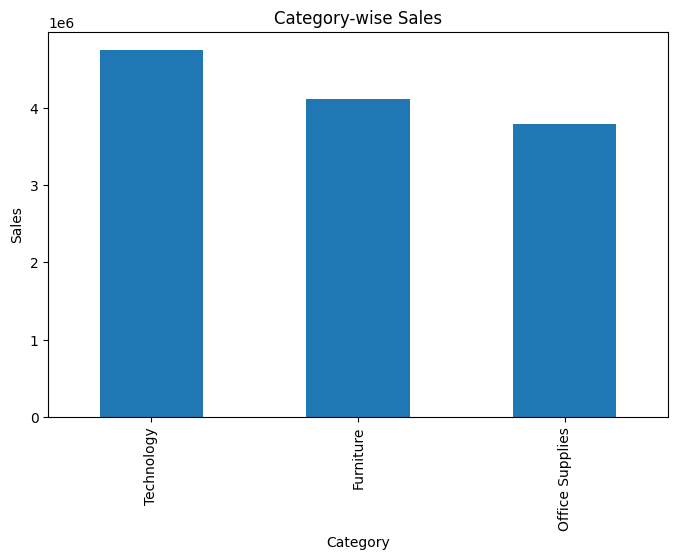

In [25]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.savefig("screenshots/category_sales.png")
plt.show()

Visualization 2 — Category-wise Profit

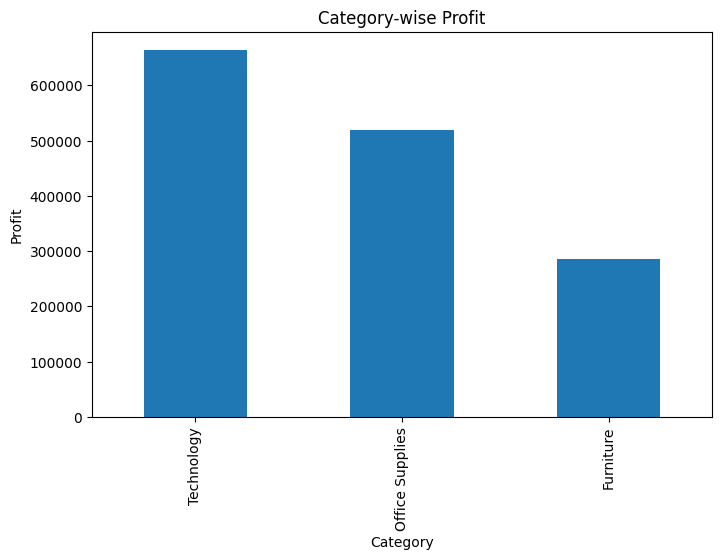

In [26]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("Category-wise Profit")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.savefig("screenshots/category_profit.png")
plt.show()

Visualization 3 — Monthly Sales Trend

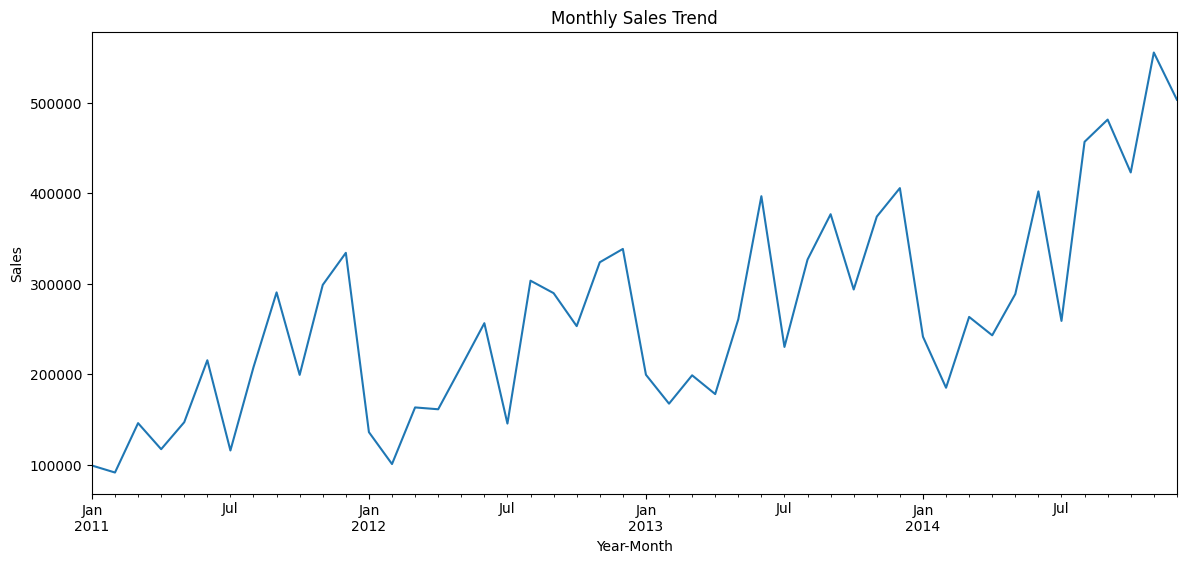

In [27]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

plt.savefig("screenshots/monthly_sales_trend.png")
plt.show()

Visualization 4 — Region-wise Sales

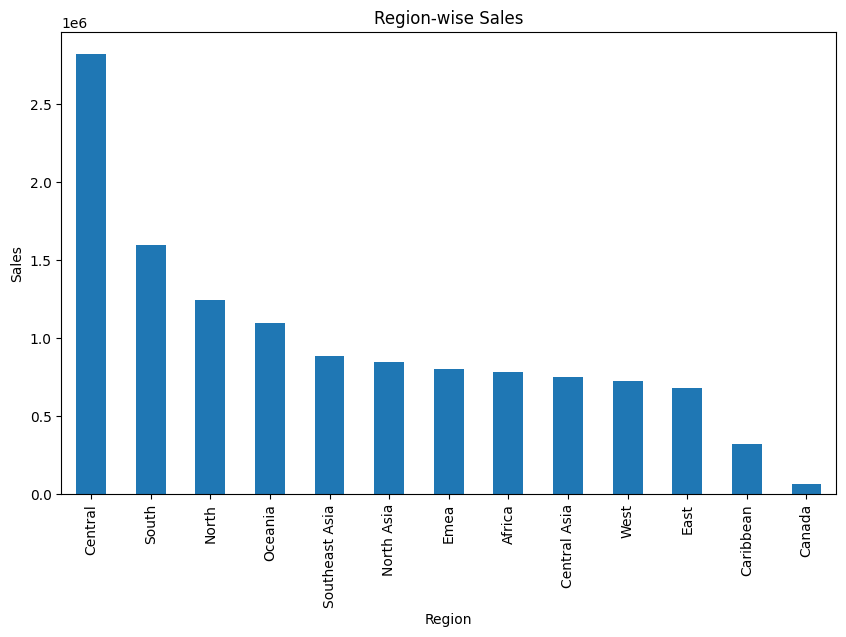

In [28]:
plt.figure(figsize=(10,6))

region_sales.plot(kind='bar')

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.savefig("screenshots/region_sales.png")
plt.show()

Visualization 5 — Discount vs Profit

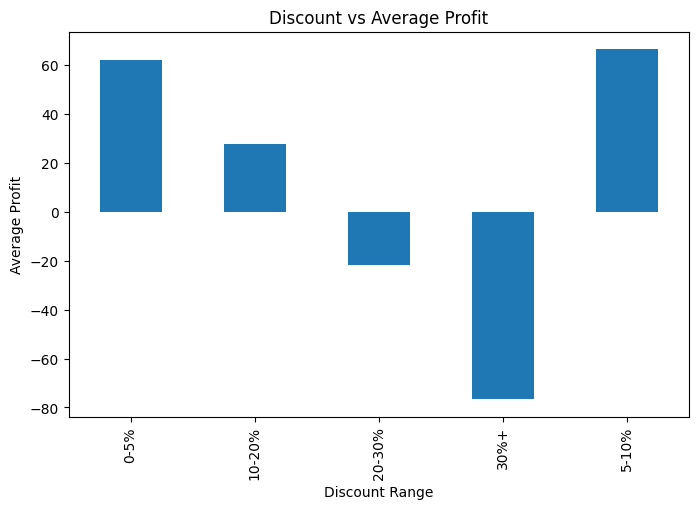

In [29]:
plt.figure(figsize=(8,5))

discount_profit.plot(kind='bar')

plt.title("Discount vs Average Profit")
plt.xlabel("Discount Range")
plt.ylabel("Average Profit")

plt.savefig("screenshots/discount_profit.png")
plt.show()

Visualization 6 — Top 10 Products

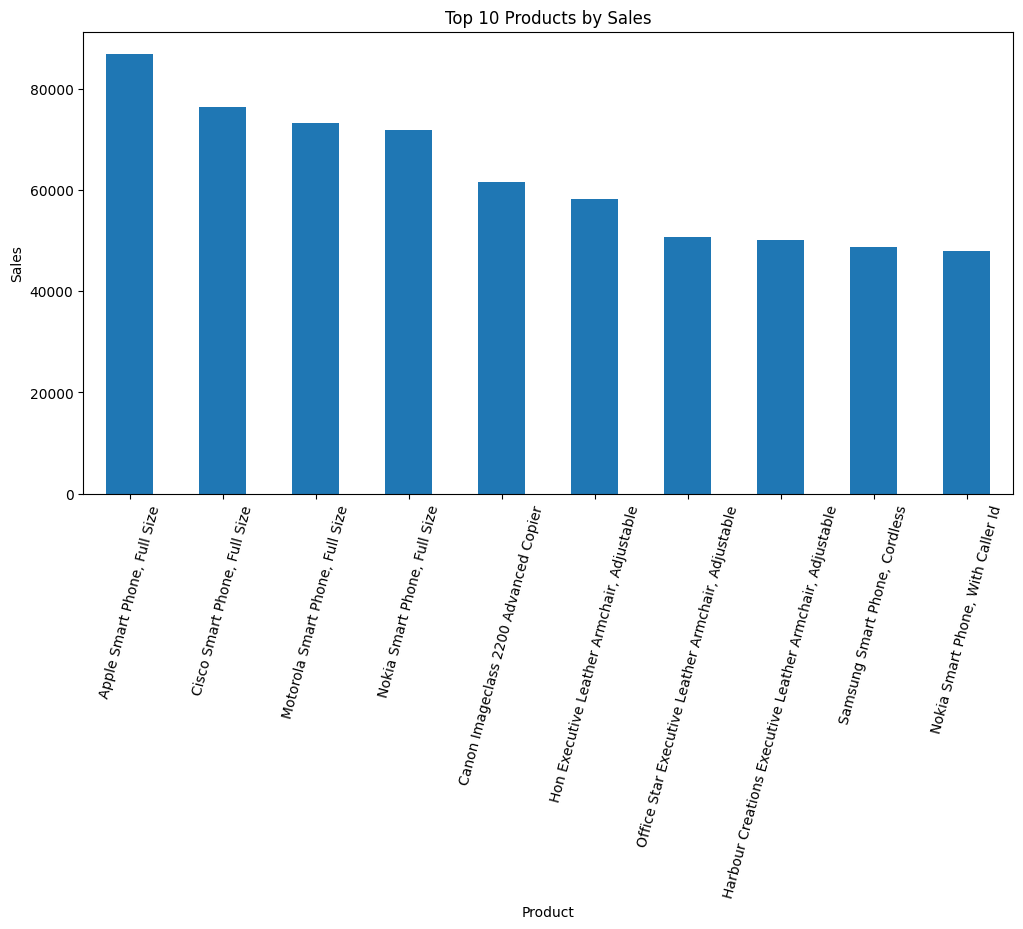

In [30]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.savefig("screenshots/top_products.png")
plt.show()

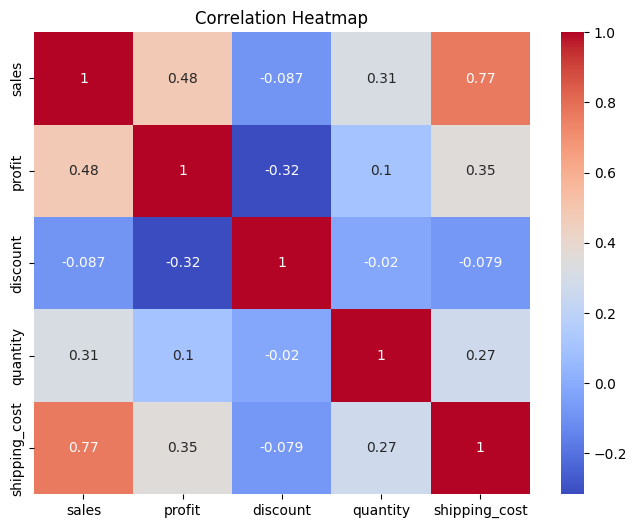

In [31]:
plt.figure(figsize=(8,6))

numeric_cols = ['sales', 'profit', 'discount', 'quantity', 'shipping_cost']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("screenshots/correlation_heatmap.png")
plt.show()

Key Business Insights
1. Technology category generates highest sales and profit.
2. Consumer segment contributes maximum revenue.
3. High discount ranges (20%+) reduce average profit significantly.
4. Some furniture products consistently generate losses.
5. Central region contributes highest sales performance.
6. Monthly sales show seasonal fluctuations and growth opportunities.

In [32]:
df = df.rename(columns={
    'column': 'row_id',
    'year_month': 'year_month_col'
})

df.to_csv("dataset/final_cleaned_superstore_sql.csv", index=False)

print(df.columns)

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'row_id', 'order_date', 'order_id',
       'order_priority', 'product_id', 'product_name', 'profit', 'quantity',
       'region', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost',
       'state', 'sub_category', 'order_year', 'order_month', 'order_quarter',
       'order_day_of_week', 'is_weekend', 'order_week', 'discount_bin',
       'profit_margin', 'sales_per_unit', 'year_month_col'],
      dtype='object')


In [34]:
df.to_csv(
    "dataset/final_cleaned_superstore_sql_clean.csv",
    index=False,
    encoding="cp1252",
    errors="replace"
)

print("Clean CSV created successfully")

Clean CSV created successfully
